### Steady state induction motor simulation.
 We aim to produce same results than Compumag TEAM problem 30a "https://www.compumag.org/jsite/images/stories/TEAM/problem30a.pdf"

We use same geometry with big surrounding airbox:

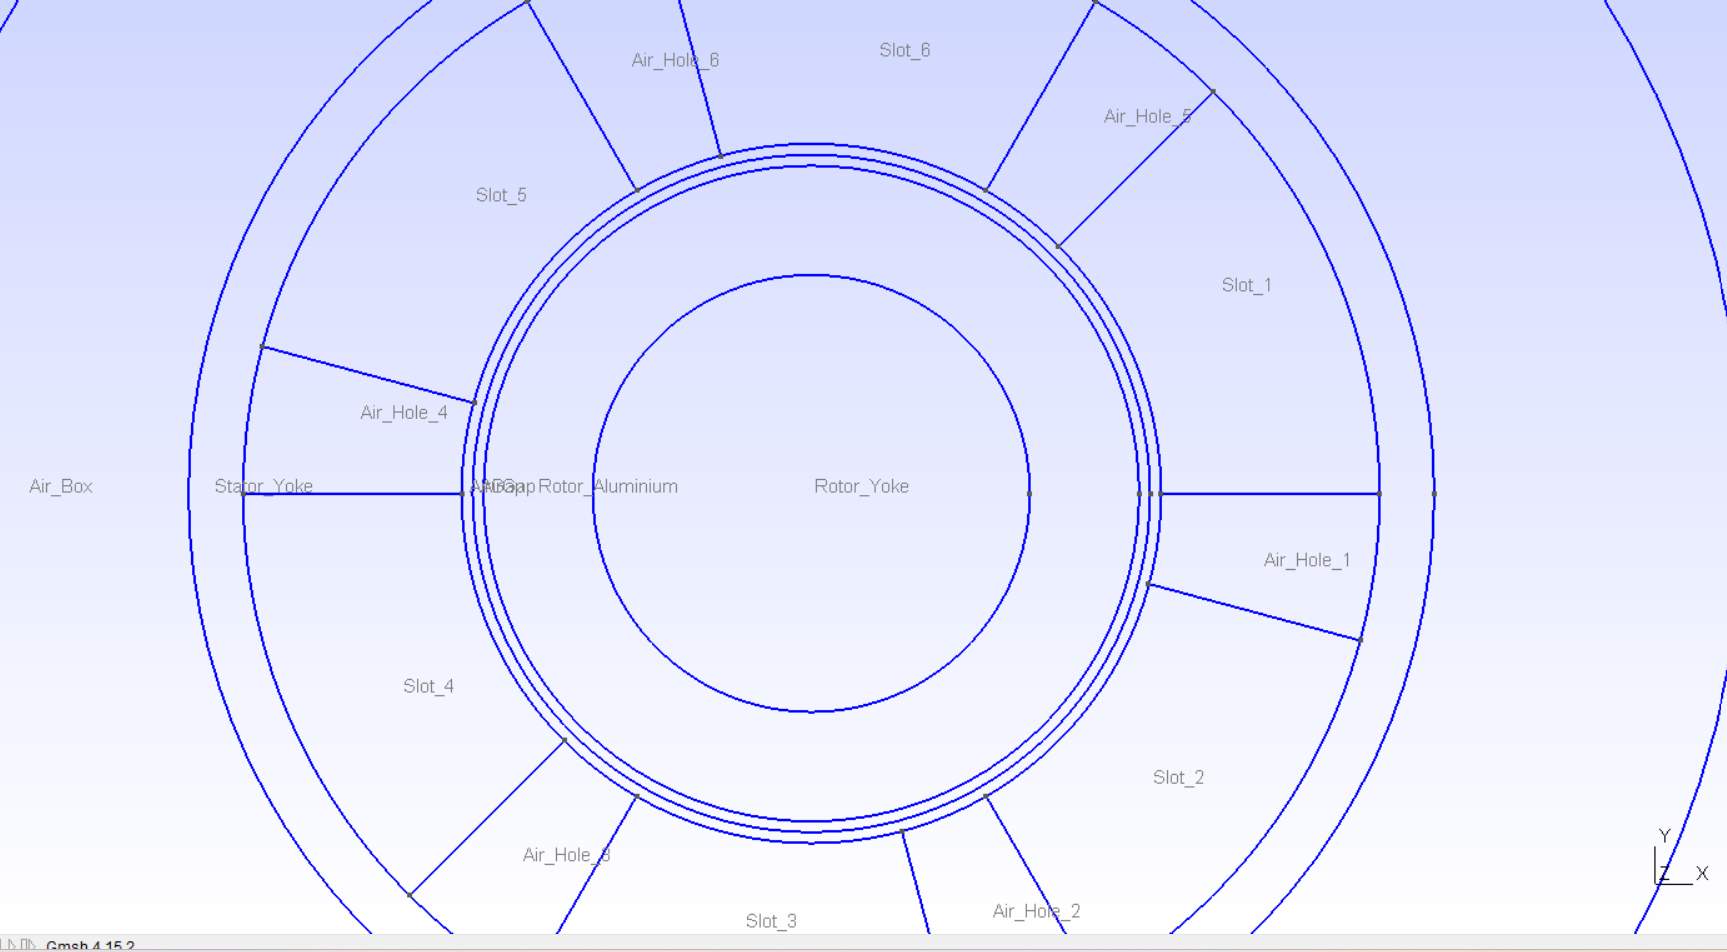


Failure to parse tags from meshio.


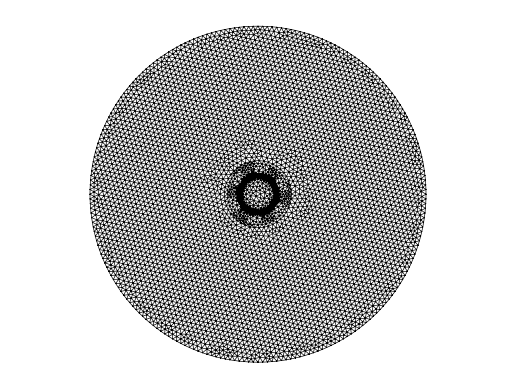

In [91]:
import meshio
from skfem import *
from skfem.helpers import dot, grad
import numpy as np

from skfem.io.meshio import from_meshio

# Add repository root to Python path. Helps to find files and modules
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))

m = meshio.read("mesh/induction_motor.msh")

mesh = from_meshio(m)

from skfem.visuals.matplotlib import draw
import matplotlib.pyplot as plt

draw(mesh)
plt.axis("equal")
plt.show()


In [92]:
from skfem import Basis, ElementTriP2

# Second order tringular elements.
e = ElementTriP2()
basis = Basis(mesh, e, intorder=6)

basis_rotor_yoke = basis.with_elements(mesh.subdomains["Rotor_Yoke"])
basis_rotor_aluminium = basis.with_elements(mesh.subdomains["Rotor_Aluminium"])
basis_stator_yoke = basis.with_elements(mesh.subdomains["Stator_Yoke"])
basis_air_box = basis.with_elements(mesh.subdomains["Air_Box"])
basis_air_holes = basis.with_elements(mesh.subdomains["Air_Hole"])
basis_air_gap = basis.with_elements(mesh.subdomains["AirGap"])

# Make FacetBasis for Maxwell Stress Tensor line integral in post-processing. Circe in the middle of airgap,
#  we use curved mesh in airgap so this construct is little awkward with compatibility between gmsh and scikit-fem...
from skfem import FacetBasis
# MST line intgral path. Circe in the middle of airgap
r_mst = 0.031
facets = mesh.facets          # (2, nfacets) for MeshTri2: corner vertices
p = mesh.p

r0 = np.sqrt(p[0, facets[0]]**2 + p[1, facets[0]]**2)
r1 = np.sqrt(p[0, facets[1]]**2 + p[1, facets[1]]**2)

mst_facets = np.where(
    np.isclose(r0, r_mst, atol=1e-6) &
    np.isclose(r1, r_mst, atol=1e-6)
)[0]


fbasis = FacetBasis(mesh, basis.elem, facets=mst_facets)

# Slot to phase current mapping
"""
Slot_1 → A-
Slot_6 → B+
Slot_5 → C-
Slot_4 → A+
Slot_3 → B-
Slot_2 → C+
"""
# Mapping dictionary
slot_bases = {
    name: basis.with_elements(mesh.subdomains[name])
    for name in mesh.subdomains
    if name.startswith("Slot_")
}

# For example Slot_1 → A+
print(slot_bases["Slot_1"])

# Evaluate slot area for to solve the current denisty
# Test winding area
from skfem import Functional
@Functional
def area(w):
    return 1.0

print()
slot_area = area.assemble(slot_bases["Slot_1"])
print("In units of m: ", slot_area)

<skfem CellBasis(MeshTri2, ElementTriP2) object>
  Number of elements: 699
  Number of DOFs: 48669
  Size: 1207872 B

In units of m:  0.0006597369865333222


Ampère's law is without considering displacement currents in low-frequencies:
 
$$

\nabla \times (\frac{1}{\mu} \nabla \times \mathbf{A})
=
\mathbf{J}_s + \mathbf{J}_e,
$$
 
where
 
- $\mathbf{J}_s$ is stator current,
- $\mathbf{J}_e$ is induced rotor current.

We can use time-harmonic approximation to solve this. We are interested in steady-state conditions,  and it is fair to assume all the fields vary sinusoidally in steady-state (because using sinusoidal currents to drive ethe system.)

$$
\frac{\partial A_z}{\partial t} = j \omega A_z
$$

In general, 

$$
\mathbf{E} = -\frac{\partial A_z}{\partial t} -\nabla V
$$

We can express electric field simply,

$$
\mathbf{E} = -j \omega A_z -\nabla V
$$

and for our induction motor example, we can neglect the voltage term $\nabla V \approx 0$, since the eddy-currents in rotor bars are induced because of magnetic field, not by drived electric potential difference $\nabla V$

The weak form of the magnetoquasistatic frequency-domain problem is


$$

\int_{\Omega}

\frac{1}{\mu} \, \nabla A_z \cdot \nabla v \
 + \int_{\Omega_c} j\omega\sigma A_z v \, d\Omega = \int_{\Omega_s} J_s v \, d\Omega

$$
with Dirichlet BC to surrounding air of A_z = 0 

We must notice that A_z is now phasor, so it does not vary in time, but is **complex number**. Multiplying it with exp(j*omega*t) and taking real part gives back time-domain.


We assume only rotor aluminium and rotor steel are conducting regions wih $\sigma >> 0 $, so the frequency domain term is only present there. Otherwise the solving is really similar to our previuous tasks. Difference is we use now complex valued matrices and all results are also in complex phasors.

In [94]:
from skfem import Functional

#######
# Material params
#######

# From compumag probelm configuration:
sigma_rotor_yoke = 1.6e6  # S/m
sigma_rotor_aluminium = 3.72e7  # S/m

mu0 = 4 * np.pi * 1e-7  # H/m
mu_rotor_yoke = 30 * mu0
mu_stator_yoke = 30 * mu0

#######
# Current params
#######

f = 60  # Hz
omega = 2 * np.pi * f  # rad/s
J_0 = 310e4

######
#  Bilinear and linear forms  :  add dtype=np.complex128 to handle complex numbers!
######

# Stifness matrix 
@BilinearForm
def stiff_lhs(A, v, w):
    return 1/w.mu*dot(grad(A), grad(v))

# Source currents
@LinearForm(dtype=np.complex128)
def slot_rhs(v, w):
    return w.J * v

# Mass matrix
@BilinearForm(dtype=np.complex128)
def mass_lhs(A, v, w):
    omega = w.omega
    sigma = w.sigma
    return 1j*omega*sigma*A*v

### Assemble left-hand-side

# RotorYoke and StatorYoke are modelled as magnetic iron
S_mat = stiff_lhs.assemble(basis_rotor_yoke, mu=mu_rotor_yoke)
S_mat += stiff_lhs.assemble(basis_stator_yoke, mu=mu_stator_yoke)

# Non magnetic regions have mu = mu0
S_mat += stiff_lhs.assemble(basis_rotor_aluminium, mu=mu0)
S_mat += stiff_lhs.assemble(basis_air_box, mu=mu0)
S_mat += stiff_lhs.assemble(basis_air_holes, mu=mu0)
S_mat += stiff_lhs.assemble(basis_air_gap, mu=mu0)

# Slots (non magnetic air with current density source) are modelled as non magnetic
for slot_basis in slot_bases.values():
    S_mat += stiff_lhs.assemble(slot_basis, mu=mu0)

# Assemble mass matrix term for conducting region Rotor_Yoke and Rotor_Aluminium
M_mat = mass_lhs.assemble(basis_rotor_yoke, omega=omega, sigma = sigma_rotor_yoke)
M_mat += mass_lhs.assemble(basis_rotor_aluminium, omega=omega, sigma = sigma_rotor_aluminium)

lhs = S_mat+M_mat

# Assemble right-hand-side
# Assign 3-phase phasor currents. These are in frequency domain.
J_A = J_0
J_B = J_0*np.exp(1j*2*np.pi/3)
J_C = J_0*np.exp(-1j*2*np.pi/3)

# Slot to phase current mapping
"""
Slot_1 → A-
Slot_6 → B+
Slot_5 → C-
Slot_4 → A+
Slot_3 → B-
Slot_2 → C+
"""

phase_map = {
    "Slot_1": -J_A,
    "Slot_2": +J_C,
    "Slot_3": -J_B,
    "Slot_4": +J_A,
    "Slot_5": -J_C,
    "Slot_6": +J_B,
}

# Assign current to slot using our dictionary mapping
b = 0
for slot, J in phase_map.items():
    b += slot_rhs.assemble(slot_bases[slot], J=J)

rhs = b

lhs, rhs = enforce(lhs, rhs, D=mesh.boundary_nodes())
A_z = solve(lhs, rhs)

A_real = np.real(A_z)      # Real part
A_imag = np.imag(A_z)      # Imaginary part
A_abs  = np.abs(A_z)       # Magnitude
A_phase = np.angle(A_z)    # Phase (radians)



In [ ]:
# Post-processing : Compute Torque with Arkkio's method

L_stack = 1.0        # We compute Torwue per unit length of the machine. Stack length is thus 1m.
airgap_thickess = 2*1e-3 ## 2mm airgap 
@Functional
def arkkio_integrand(w):
    gradA = w['A'].grad  
    Bx = gradA[1]
    By = -gradA[0]

    x, y = w.x                    # global coordinates at quadrature points
    r = np.sqrt(x**2 + y**2)
    
    # Arkkio torque integrand for complex phasors
    return np.real((x*Bx+y*By)*np.conj(-y*Bx+x*By)) / r

integral = arkkio_integrand.assemble(
    basis_air_gap, A=basis_air_gap.interpolate(A_z)
)

torque_arkkio = (L_stack / (mu0 * (airgap_thickess))) * integral

print(f"Reference Torque: 3.8259 Nm")
print()
print(f"Python Torque Arkkio: {torque_arkkio} Nm")

# Maxwell Stress Tensor (MST) torque calculation

# Interpolate your solution onto the facets
A_f = fbasis.interpolate(A_z)
@Functional
def mst_torque(w):

    gradA = w["A"].grad

    Bx = gradA[1]
    By = -gradA[0]

    x, y = w.x
    nx, ny = w.n

    # Compute the Complex phasor Maxwell stress tensor components
    B2 = np.real(Bx*np.conj(Bx) + By*np.conj(By))

    Txx = np.real(Bx*np.conj(Bx) - B2)/mu0
    Txy = np.real(Bx*np.conj(By))/mu0
    Tyx = Txy
    Tyy = np.real(By*np.conj(By) - B2)/mu0

    fx = Txx*nx + Txy*ny
    fy = Tyx*nx + Tyy*ny

    return x*fy - y*fx

torque_mst = mst_torque.assemble(
    fbasis,
    A=A_f,
)

print(f"Python Torque MST: {torque_mst} Nm")

Reference Torque: 3.8259 Nm

Python Torque Arkkio: 3.8122676292664606 Nm
Python Torque MST: 3.8127595598218735 Nm


Our result agree well with Compumag TEAM Workshop Problem 30a,  when RPM = 0
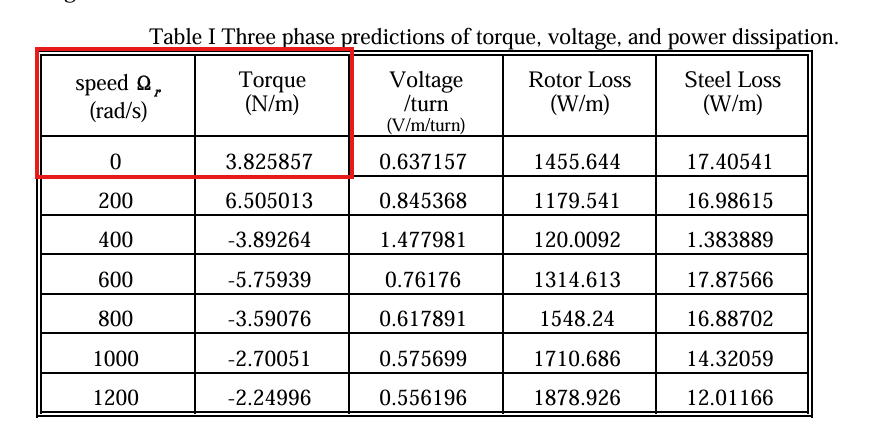

Using curved mesh in airgap region help to get the final decimals right. Without it integrating with Arkkio gives error when discretising circular region with straigt lines.